# UAH Sliding Window Feature Extraction

## Objective

This notebook converts instantaneous sensor measurements into window-based statistical features.

Each window represents approximately 3 seconds of driving behaviour.

The generated features will be used as the final input for machine learning models.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
feature_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/master_dataset_features.csv"

feature_df = pd.read_csv(feature_path)

feature_df.head()

,timestamp,active,acc_x,acc_y,acc_z,acc_x_kf,acc_y_kf,acc_z_kf,roll,pitch,...,extra_3,extra_4,acc_resultant,acc_horizontal,acc_vertical,speed_delta,heading_delta,roll_delta,pitch_delta,yaw_delta
0,6.94,1,0.017,-0.011,0.018,-0.005,0.008,0.018,-1.523,0.015,...,0,0,0.027092,0.020248,0.018,0.0,0.0,0.000,0.000,0.000
1,7.03,1,0.046,0.007,0.019,0.016,-0.002,0.018,-1.522,0.012,...,0,0,0.050259,0.046530,0.019,0.0,0.0,0.001,-0.003,0.000
2,7.14,1,0.052,-0.016,0.027,0.037,-0.005,0.018,-1.520,0.014,...,0,0,0.060737,0.054406,0.027,0.0,0.0,0.002,0.002,-0.001
3,7.24,1,0.015,-0.016,0.026,0.038,-0.009,0.024,-1.523,0.014,...,0,0,0.034015,0.021932,0.026,0.0,0.0,-0.003,0.000,0.000
4,7.34,1,-0.014,-0.017,0.040,0.012,-0.016,0.032,-1.525,0.012,...,0,0,0.045662,0.022023,0.040,0.0,0.0,-0.002,-0.002,0.000


In [5]:
print("Shape:", feature_df.shape)

feature_df.info()

Shape: (6170, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6170 entries, 0 to 6169
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       6170 non-null   float64
 1   active          6170 non-null   int64  
 2   acc_x           6170 non-null   float64
 3   acc_y           6170 non-null   float64
 4   acc_z           6170 non-null   float64
 5   acc_x_kf        6170 non-null   float64
 6   acc_y_kf        6170 non-null   float64
 7   acc_z_kf        6170 non-null   float64
 8   roll            6170 non-null   float64
 9   pitch           6170 non-null   float64
 10  yaw             6170 non-null   float64
 11  speed           6170 non-null   float64
 12  latitude        6170 non-null   float64
 13  longitude       6170 non-null   float64
 14  altitude        6170 non-null   float64
 15  gps_quality     6170 non-null   int64  
 16  satellites      6170 non-null   int64  
 17  heading        

In [6]:
SAMPLING_RATE = 10      # Hz
WINDOW_SECONDS = 3      # seconds

WINDOW_SIZE = SAMPLING_RATE * WINDOW_SECONDS

print("Window Size:", WINDOW_SIZE)

Window Size: 30


In [7]:
window_features = [

    "acc_resultant",

    "acc_horizontal",

    "speed",

    "speed_delta",

    "roll",

    "pitch",

    "yaw"

]

window_features

['acc_resultant',
 'acc_horizontal',
 'speed',
 'speed_delta',
 'roll',
 'pitch',
 'yaw']

In [8]:
window_size = WINDOW_SIZE

first_window = feature_df.iloc[:window_size]

print(first_window.shape)

first_window.head()

(30, 30)


,timestamp,active,acc_x,acc_y,acc_z,acc_x_kf,acc_y_kf,acc_z_kf,roll,pitch,...,extra_3,extra_4,acc_resultant,acc_horizontal,acc_vertical,speed_delta,heading_delta,roll_delta,pitch_delta,yaw_delta
0,6.94,1,0.017,-0.011,0.018,-0.005,0.008,0.018,-1.523,0.015,...,0,0,0.027092,0.020248,0.018,0.0,0.0,0.000,0.000,0.000
1,7.03,1,0.046,0.007,0.019,0.016,-0.002,0.018,-1.522,0.012,...,0,0,0.050259,0.046530,0.019,0.0,0.0,0.001,-0.003,0.000
2,7.14,1,0.052,-0.016,0.027,0.037,-0.005,0.018,-1.520,0.014,...,0,0,0.060737,0.054406,0.027,0.0,0.0,0.002,0.002,-0.001
3,7.24,1,0.015,-0.016,0.026,0.038,-0.009,0.024,-1.523,0.014,...,0,0,0.034015,0.021932,0.026,0.0,0.0,-0.003,0.000,0.000
4,7.34,1,-0.014,-0.017,0.040,0.012,-0.016,0.032,-1.525,0.012,...,0,0,0.045662,0.022023,0.040,0.0,0.0,-0.002,-0.002,0.000


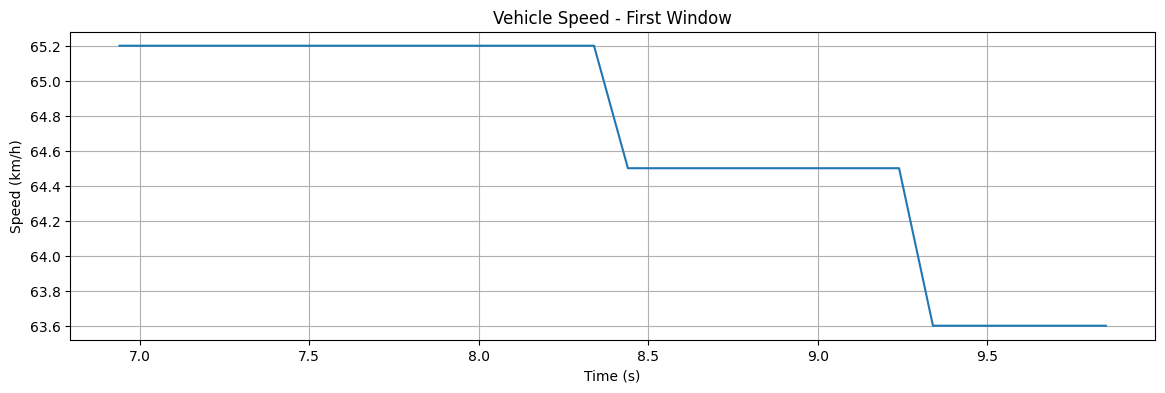

In [9]:
plt.figure(figsize=(14,4))

plt.plot(
    first_window["timestamp"],
    first_window["speed"]
)

plt.title("Vehicle Speed - First Window")

plt.xlabel("Time (s)")
plt.ylabel("Speed (km/h)")

plt.grid(True)

plt.show()

In [10]:
first_window["speed"].describe()

,speed
count,30.00000
mean,64.67000
std,0.62541
min,63.60000
25%,64.50000
50%,64.85000
75%,65.20000
max,65.20000


In [11]:
stats = {

    "speed_mean": first_window["speed"].mean(),

    "speed_std": first_window["speed"].std(),

    "speed_min": first_window["speed"].min(),

    "speed_max": first_window["speed"].max(),

    "speed_median": first_window["speed"].median(),

    "speed_rms": np.sqrt(
        np.mean(first_window["speed"]**2)
    )

}

stats

{'speed_mean': np.float64(64.66999999999999),
 'speed_std': 0.6254102102096539,
 'speed_min': 63.6,
 'speed_max': 65.2,
 'speed_median': 64.85,
 'speed_rms': np.float64(64.67292323685393)}

In [12]:
def extract_statistics(signal):

    features = {}

    features["mean"] = signal.mean()

    features["std"] = signal.std()

    features["min"] = signal.min()

    features["max"] = signal.max()

    features["median"] = signal.median()

    features["rms"] = np.sqrt(np.mean(signal**2))

    return features

In [13]:
extract_statistics(first_window["speed"])

{'mean': np.float64(64.66999999999999),
 'std': 0.6254102102096539,
 'min': 63.6,
 'max': 65.2,
 'median': 64.85,
 'rms': np.float64(64.67292323685393)}

In [14]:
extract_statistics(
    first_window["acc_resultant"]
)

{'mean': np.float64(0.04155660035870173),
 'std': 0.015206020811659948,
 'min': 0.0193390796058137,
 'max': 0.075226325179421,
 'median': 0.0379468835534368,
 'rms': np.float64(0.04416408797503536)}

In [15]:
extract_statistics(
    first_window["roll"]
)

{'mean': np.float64(-1.5291),
 'std': 0.004551240831185302,
 'min': -1.538,
 'max': -1.52,
 'median': -1.529,
 'rms': np.float64(1.5291065474103933)}

In [16]:
def extract_window_features(window, feature_list):

    window_stats = {}

    for feature in feature_list:

        stats = extract_statistics(window[feature])

        for stat_name, stat_value in stats.items():

            column_name = f"{feature}_{stat_name}"

            window_stats[column_name] = stat_value

    return window_stats

In [17]:
window_features_dict = extract_window_features(
    first_window,
    window_features
)

len(window_features_dict)

42

In [18]:
window_features_dict

{'acc_resultant_mean': np.float64(0.04155660035870173),
 'acc_resultant_std': 0.015206020811659948,
 'acc_resultant_min': 0.0193390796058137,
 'acc_resultant_max': 0.075226325179421,
 'acc_resultant_median': 0.0379468835534368,
 'acc_resultant_rms': np.float64(0.04416408797503536),
 'acc_horizontal_mean': np.float64(0.03625871712142948),
 'acc_horizontal_std': 0.01567796936759329,
 'acc_horizontal_min': 0.0122065556157337,
 'acc_horizontal_max': 0.0751664818918645,
 'acc_horizontal_median': 0.033128536687460006,
 'acc_horizontal_rms': np.float64(0.03939923857132263),
 'speed_mean': np.float64(64.66999999999999),
 'speed_std': 0.6254102102096539,
 'speed_min': 63.6,
 'speed_max': 65.2,
 'speed_median': 64.85,
 'speed_rms': np.float64(64.67292323685393),
 'speed_delta_mean': np.float64(-0.05333333333333338),
 'speed_delta_std': 0.20465839213495354,
 'speed_delta_min': -0.8999999999999986,
 'speed_delta_max': 0.0,
 'speed_delta_median': 0.0,
 'speed_delta_rms': np.float64(0.20816659994661

In [19]:
all_windows = []

for start in range(
    0,
    len(feature_df) - window_size + 1
):

    window = feature_df.iloc[
        start:start + window_size
    ]

    features = extract_window_features(
        window,
        window_features
    )

    all_windows.append(features)

In [20]:
window_df = pd.DataFrame(all_windows)

window_df.head()

,acc_resultant_mean,acc_resultant_std,acc_resultant_min,acc_resultant_max,acc_resultant_median,acc_resultant_rms,acc_horizontal_mean,acc_horizontal_std,acc_horizontal_min,acc_horizontal_max,...,pitch_min,pitch_max,pitch_median,pitch_rms,yaw_mean,yaw_std,yaw_min,yaw_max,yaw_median,yaw_rms
0,0.041557,0.015206,0.019339,0.075226,0.037947,0.044164,0.036259,0.015678,0.012207,0.075166,...,0.012,0.032,0.0220,0.021821,0.019100,0.005182,0.011,0.025,0.0215,0.019768
1,0.041732,0.015063,0.019339,0.075226,0.037947,0.044282,0.036556,0.015447,0.012207,0.075166,...,0.012,0.032,0.0220,0.022052,0.019533,0.005111,0.011,0.025,0.0220,0.020169
2,0.041103,0.015089,0.019339,0.075226,0.036665,0.043698,0.035783,0.015511,0.012207,0.075166,...,0.012,0.032,0.0225,0.022413,0.020033,0.005082,0.011,0.027,0.0220,0.020647
3,0.039805,0.015016,0.019339,0.075226,0.034974,0.042455,0.034164,0.016026,0.005831,0.075166,...,0.012,0.032,0.0230,0.022767,0.020667,0.005101,0.011,0.030,0.0220,0.021267
4,0.040324,0.015078,0.019339,0.075226,0.036665,0.042963,0.035077,0.016086,0.005831,0.075166,...,0.012,0.032,0.0230,0.023116,0.021333,0.005101,0.011,0.031,0.0225,0.021915


In [21]:
print(window_df.shape)

(6141, 42)


In [22]:
window_df.isnull().sum()

,0
acc_resultant_mean,0
acc_resultant_std,0
acc_resultant_min,0
acc_resultant_max,0
acc_resultant_median,0
acc_resultant_rms,0
acc_horizontal_mean,0
acc_horizontal_std,0
acc_horizontal_min,0
acc_horizontal_max,0


In [23]:
window_df.describe().T

,count,mean,std,min,25%,50%,75%,max
acc_resultant_mean,6141.0,0.047292,0.016425,0.025106,0.037767,0.043955,0.051514,0.192325
acc_resultant_std,6141.0,0.022065,0.007668,0.008813,0.016708,0.020335,0.025136,0.068323
acc_resultant_min,6141.0,0.013424,0.009188,0.002449,0.008485,0.012124,0.015937,0.149255
acc_resultant_max,6141.0,0.101992,0.033322,0.048425,0.078147,0.096089,0.117533,0.252256
acc_resultant_median,6141.0,0.044174,0.016494,0.022136,0.035163,0.040792,0.048372,0.190751
acc_resultant_rms,6141.0,0.052199,0.017582,0.027482,0.041676,0.048389,0.057161,0.194533
acc_horizontal_mean,6141.0,0.041903,0.015994,0.021155,0.032904,0.038462,0.046111,0.187647
acc_horizontal_std,6141.0,0.022520,0.007764,0.010626,0.017192,0.020598,0.025595,0.067851
acc_horizontal_min,6141.0,0.008104,0.008269,0.000000,0.004243,0.006403,0.010000,0.139904
acc_horizontal_max,6141.0,0.098453,0.033721,0.042202,0.075186,0.091395,0.110766,0.251205


In [24]:
output_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed"

window_df.to_csv(
    os.path.join(
        output_path,
        "window_features_D1_NORMAL1.csv"
    ),
    index=False
)

print("Sliding window dataset saved successfully.")

Sliding window dataset saved successfully.
